In [8]:
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [9]:
# Paths
PROJECT_ROOT = Path.cwd().resolve().parents[0]
DATA_ROOT = PROJECT_ROOT / "data" / "modern_dataset"

TRAIN_DIR = DATA_ROOT / "Train"
VAL_DIR = DATA_ROOT / "Validation"
TEST_DIR = DATA_ROOT / "Test"

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("Train exists:", TRAIN_DIR.exists())
print("Validation exists:", VAL_DIR.exists())
print("Test exists:", TEST_DIR.exists())

PROJECT_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main
DATA_ROOT: C:\Users\zakiz\Downloads\COMP-487-Project-1-main\data\modern_dataset
Train exists: True
Validation exists: True
Test exists: True


In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 10923 files belonging to 2 classes.
Found 2341 files belonging to 2 classes.
Found 2635 files belonging to 2 classes.


In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [14]:
base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(inputs, outputs)

In [15]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.9587 - loss: 0.1069 - val_accuracy: 0.9825 - val_loss: 0.0464
Epoch 2/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 357s 1s/step - accuracy: 0.9803 - loss: 0.0551 - val_accuracy: 0.9829 - val_loss: 0.0381
Epoch 3/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.9837 - loss: 0.0442 - val_accuracy: 0.9872 - val_loss: 0.0320
Epoch 4/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 354s 1s/step - accuracy: 0.9865 - loss: 0.0362 - val_accuracy: 0.9868 - val_loss: 0.0317
Epoch 5/5
342/342 ━━━━━━━━━━━━━━━━━━━━ 350s 1s/step - accuracy: 0.9858 - loss: 0.0374 - val_accuracy: 0.9872 - val_loss: 0.0301


In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)

83/83 ━━━━━━━━━━━━━━━━━━━━ 72s 859ms/step - accuracy: 0.9856 - loss: 0.0373
Test accuracy: 0.9855787754058838


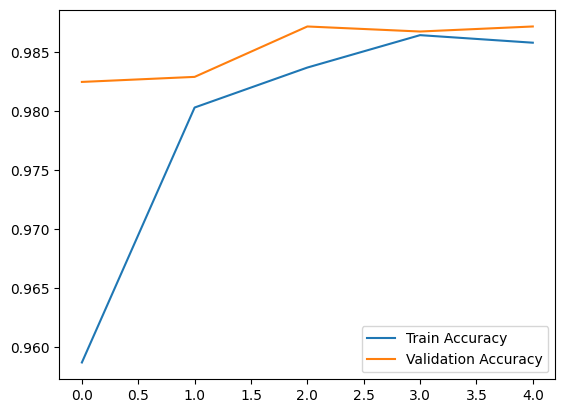

In [18]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

In [30]:
class_names = ['Fake', 'Real']

sample_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMAGE_SIZE,
    batch_size=9,
    shuffle=True,
    seed=42
)

Found 2635 files belonging to 2 classes.


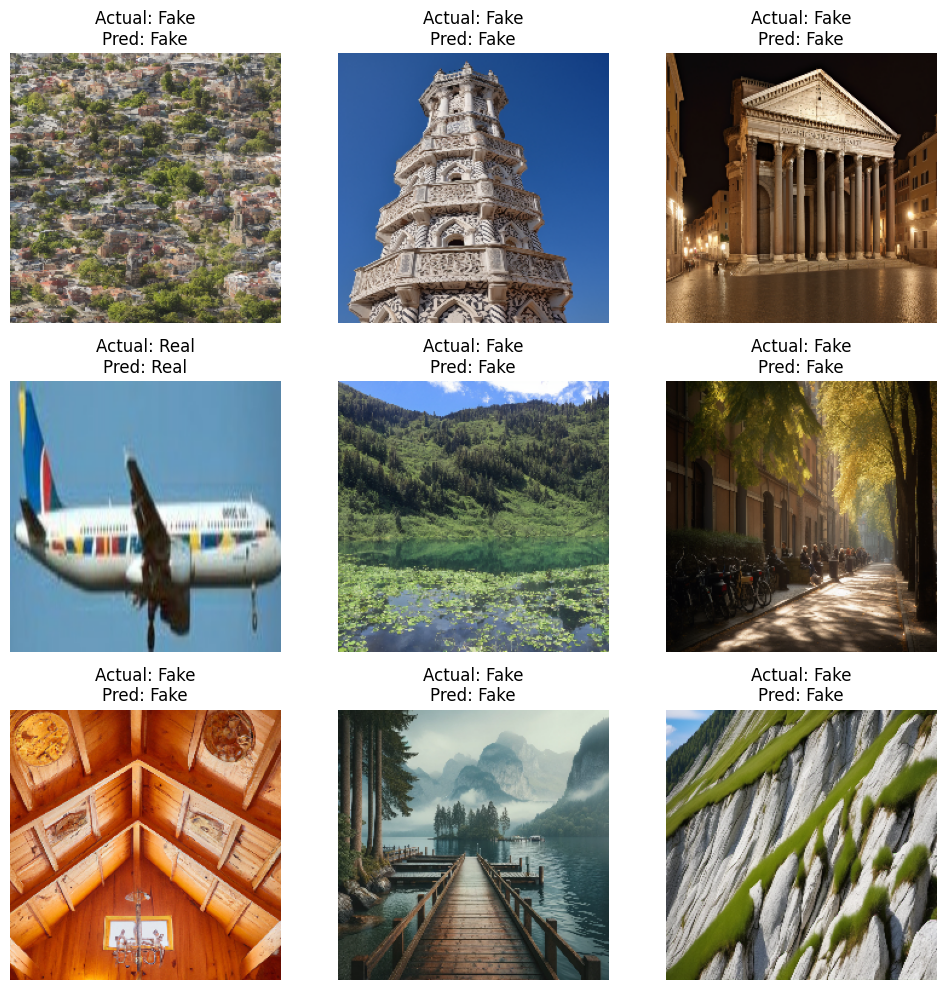

In [31]:
plt.figure(figsize=(10, 10))

for images, labels in sample_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        img = images[i]
        label = int(labels[i].numpy())

        pred = model.predict(tf.expand_dims(img, axis=0), verbose=0)
        pred_label = 1 if pred[0][0] > 0.5 else 0

        plt.imshow(img.numpy().astype("uint8"))
        plt.title(f"Actual: {class_names[label]}\nPred: {class_names[pred_label]}")
        plt.axis("off")

plt.tight_layout()
plt.show()